# 🛡️ GCN Champion: Baseline Optimization & Robustness Testing

## Environment Setup & High-Performance Engines

In [14]:
import os
import ssl
import certifi
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import dropout_edge
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import torch_geometric.transforms as T

# 1. SSL & Device Setup
os.environ['SSL_CERT_FILE'] = certifi.where()
ssl._create_default_https_context = ssl._create_unverified_context
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# 2. Winning GCN Hyperparameters (From your 89.48% run)
GCN_LR = 0.01
GCN_HID_DIM = 64
GCN_DROPOUT = 0.3

topic_map = {
    0: "Theory", 1: "Reinforcement_Learning", 2: "Genetic_Algorithms", 
    3: "Neural_Networks", 4: "Probabilistic_Methods", 5: "Case_Based", 6: "Rule_Learning"
}

# 3. Reusable Engines
def run_experiment(model, data, lr, epochs=200, use_dropedge=False, dropedge_p=0.2, use_scheduler=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
    # Initialize the Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
    
    criterion = torch.nn.CrossEntropyLoss()
    train_losses, val_losses = [], []
    
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        if use_dropedge:
            from torch_geometric.utils import dropout_edge
            train_edge_index, _ = dropout_edge(data.edge_index, p=dropedge_p, training=True)
        else:
            train_edge_index = data.edge_index
            
        out = model(data.x, train_edge_index)
        t_loss = criterion(out[data.train_mask], data.y[data.train_mask])
        t_loss.backward()
        optimizer.step()
        train_losses.append(t_loss.item())
        
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            v_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_losses.append(v_loss.item())
            
            # This is the line that was missing!
            if use_scheduler:
                scheduler.step(v_loss)
            
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1)[data.test_mask].cpu().numpy()
        trues = data.y[data.test_mask].cpu().numpy()
        
    test_acc = accuracy_score(trues, preds)
    test_f1 = f1_score(trues, preds, average='macro')
    return train_losses, val_losses, test_acc, test_f1

def plot_advanced_diagnostics(model, data, title):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        embeddings = out.cpu().numpy()
        preds = out.argmax(dim=1)[data.test_mask].cpu().numpy()
        trues = data.y[data.test_mask].cpu().numpy()
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Confusion Matrix
    cm = confusion_matrix(trues, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
                xticklabels=topic_map.values(), yticklabels=topic_map.values())
    axes[0].set_title(f"Confusion Matrix: {title}")
    axes[0].tick_params(axis='x', rotation=45)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)
    labels = data.y.cpu().numpy()
    for i in range(dataset_exp1.num_classes):
        indices = np.where(labels == i)
        axes[1].scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], label=topic_map[i], alpha=0.7, s=20)
    
    axes[1].set_title(f"t-SNE: {title}")
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

print("GCN Setup Complete!")

GCN Setup Complete!


## 🏗️ GCN Architectural Innovation & Residual Mapping

In [15]:
# Standard 2-Layer GCN
class GCN_Standard(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_p):
        super(GCN_Standard, self).__init__()
        self.dropout_p = dropout_p
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        return self.conv2(x, edge_index)

# Experimental 3-Layer GCN with a Residual (Skip) Connection
class GCN_Residual(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_p):
        super(GCN_Residual, self).__init__()
        self.dropout_p = dropout_p
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv_res = GCNConv(hidden_channels, hidden_channels) # The middle layer
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Layer 1
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        h1 = F.relu(self.conv1(x, edge_index))
        
        # Layer 2 (Residual Block)
        h1_dropped = F.dropout(h1, p=self.dropout_p, training=self.training)
        h2 = F.relu(self.conv_res(h1_dropped, edge_index))
        
        # THE RESIDUAL LINK: Add Layer 1's output directly to Layer 2's output
        x_res = h2 + h1 
        
        # Layer 3
        x_res = F.dropout(x_res, p=self.dropout_p, training=self.training)
        return self.conv2(x_res, edge_index)

In [16]:
def plot_experiment(train_losses, val_losses, title, acc, f1):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='teal', linewidth=2, alpha=0.8)
    plt.plot(val_losses, label='Validation Loss', color='salmon', linewidth=2)
    plt.title(f"{title}\nTest Accuracy: {acc*100:.2f}% | Macro-F1: {f1*100:.2f}%", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Experimental Roadmap
## We evaluate four distinct technical variants:

### Exp 1 (Normalization Ablation): Testing the model's sensitivity to raw feature magnitudes without row-normalization.

### Exp 2 (Structural Regularization): Utilizing 20% Edge Dropout to force the model to learn more robust, path-independent node representations.

### Exp 3 (Deep GCN Innovation): Implementing Residual (Skip) Connections to observe if identity mappings improve feature preservation across deep layers.

### Exp 4 (Optimization Refinement): Applying an Adaptive LR Scheduler to stabilize convergence during the final stages of the baseline training.

Training GCN Without Feature Normalization...
Exp 1 Results -> Acc: 89.67% | F1: 88.81%


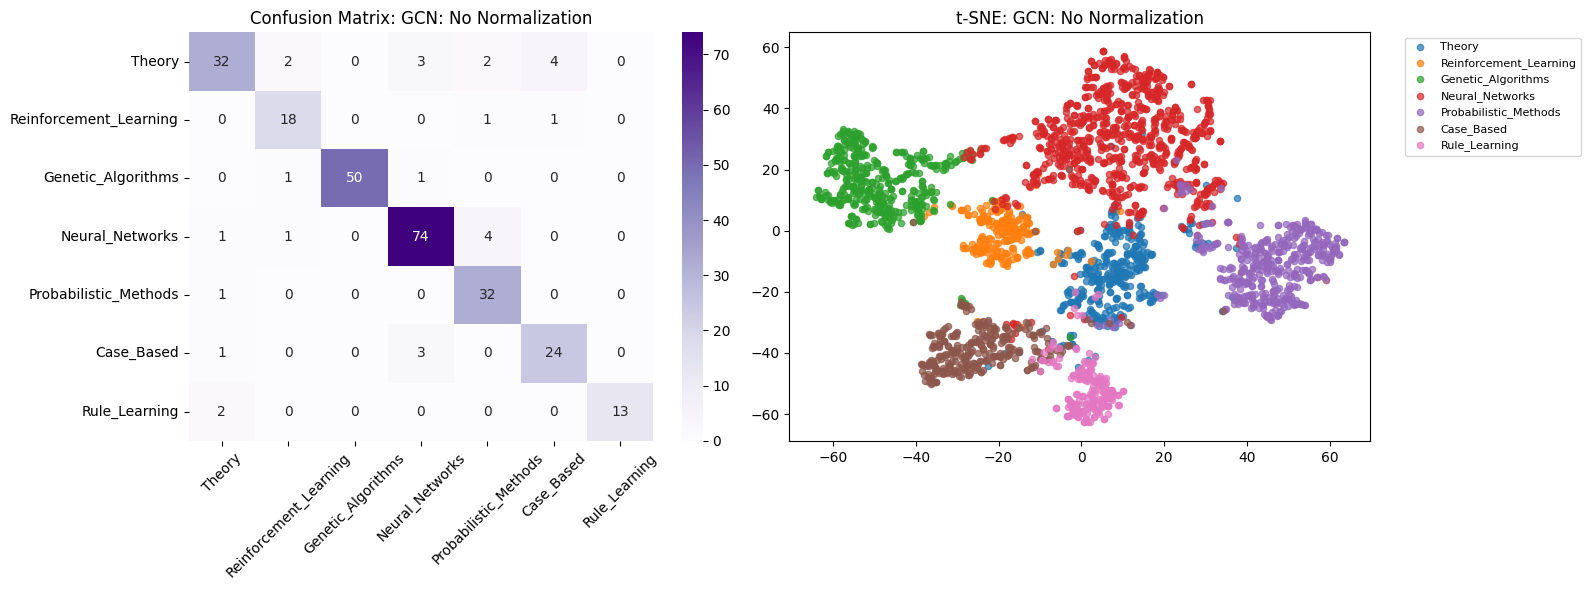


Training GCN With 20% Edge Dropout...
Exp 2 Results -> Acc: 91.14% | F1: 91.07%


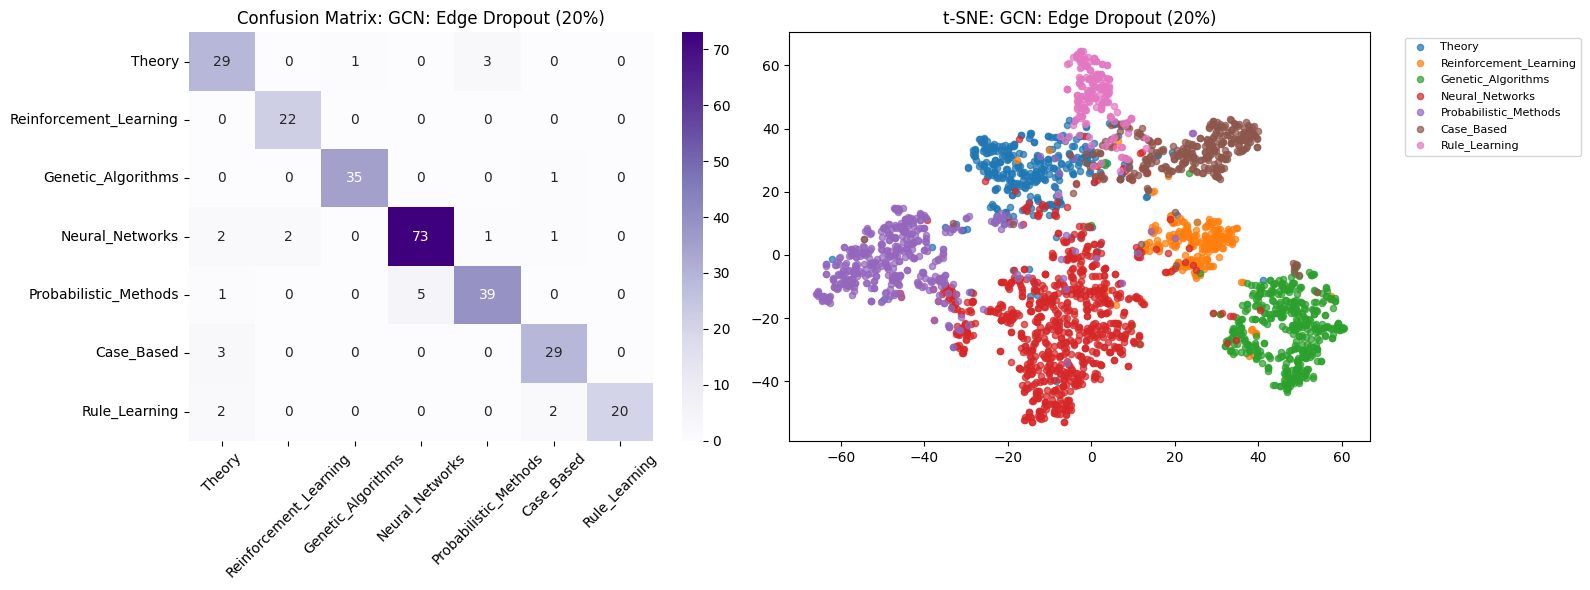


Training GCN With Residual Links...
Exp 3 Results -> Acc: 89.67% | F1: 89.57%


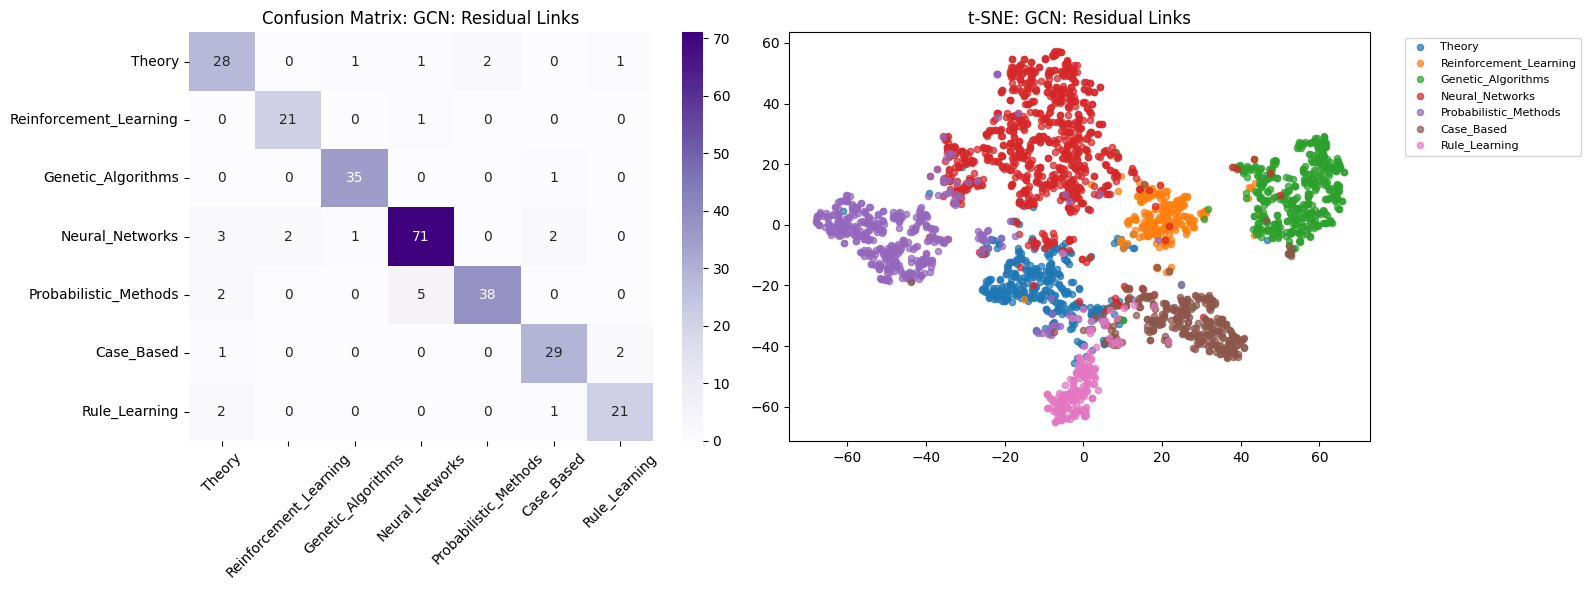

--- EXPERIMENT 4: DYNAMIC LEARNING RATE (GCN) ---


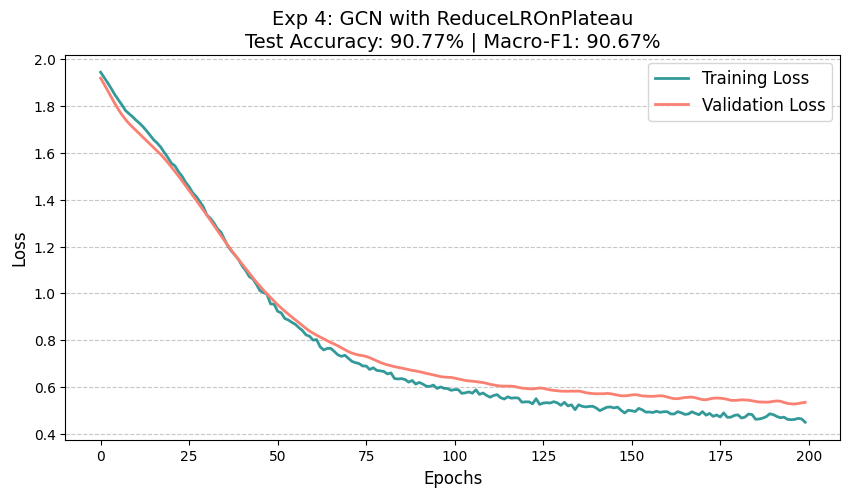

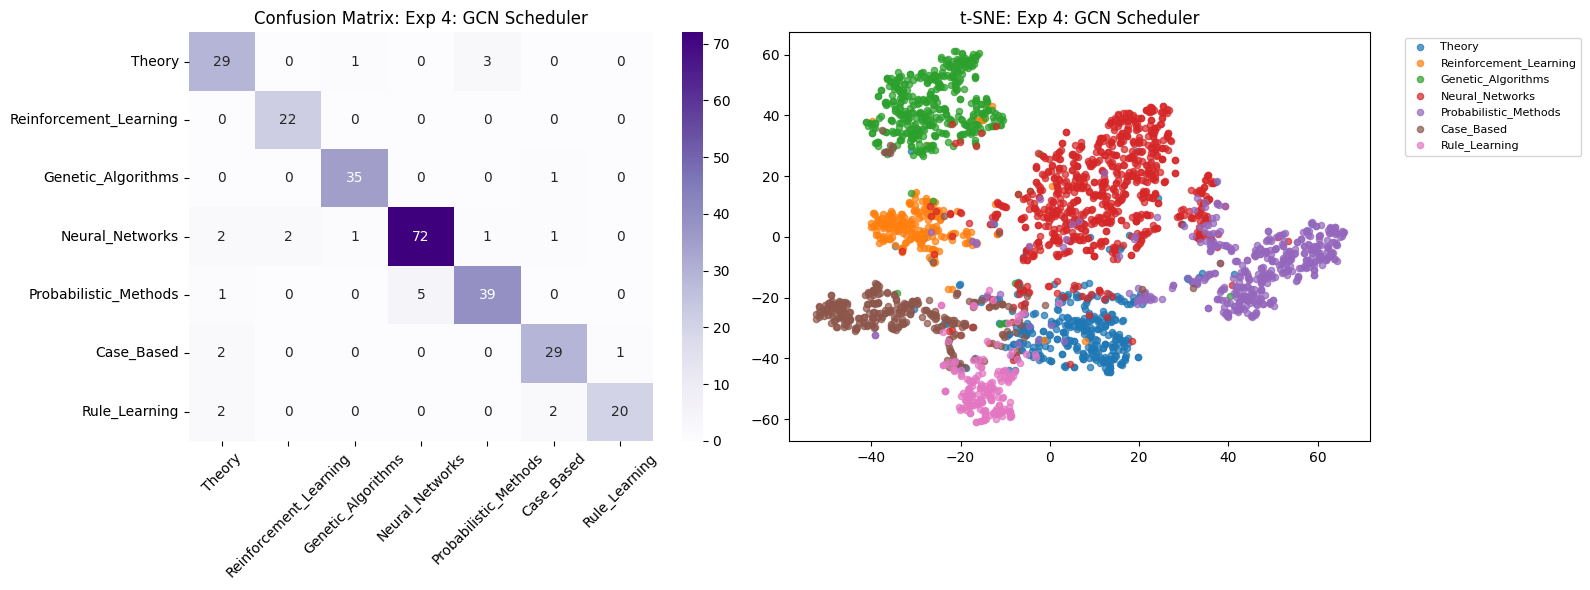

In [17]:
# --- DATA LOADING ---
transform_no_norm = T.Compose([T.RandomNodeSplit(split='train_rest', num_val=0.1, num_test=0.1)])
dataset_exp1 = Planetoid(root='./data/Cora', name='Cora', transform=transform_no_norm)
data_no_norm = dataset_exp1[0].to(device)

transform_norm = T.Compose([T.NormalizeFeatures(), T.RandomNodeSplit(split='train_rest', num_val=0.1, num_test=0.1)])
dataset_exp2 = Planetoid(root='./data/Cora', name='Cora', transform=transform_norm)
data_norm = dataset_exp2[0].to(device)

in_c, out_c = dataset_exp1.num_features, dataset_exp1.num_classes

# --- EXP 1: NO NORMALIZATION ---
print("Training GCN Without Feature Normalization...")
gcn_exp1 = GCN_Standard(in_c, GCN_HID_DIM, out_c, GCN_DROPOUT).to(device)
_, _, acc1, f1_1 = run_experiment(gcn_exp1, data_no_norm, GCN_LR)
print(f"Exp 1 Results -> Acc: {acc1*100:.2f}% | F1: {f1_1*100:.2f}%")
plot_advanced_diagnostics(gcn_exp1, data_no_norm, "GCN: No Normalization")

# --- EXP 2: EDGE DROPOUT (20%) ---
print("\nTraining GCN With 20% Edge Dropout...")
gcn_exp2 = GCN_Standard(in_c, GCN_HID_DIM, out_c, GCN_DROPOUT).to(device)
_, _, acc2, f1_2 = run_experiment(gcn_exp2, data_norm, GCN_LR, use_dropedge=True, dropedge_p=0.2)
print(f"Exp 2 Results -> Acc: {acc2*100:.2f}% | F1: {f1_2*100:.2f}%")
plot_advanced_diagnostics(gcn_exp2, data_norm, "GCN: Edge Dropout (20%)")

# --- EXP 3: RESIDUAL LINKS ---
print("\nTraining GCN With Residual Links...")
gcn_exp3 = GCN_Residual(in_c, GCN_HID_DIM, out_c, GCN_DROPOUT).to(device)
_, _, acc3, f1_3 = run_experiment(gcn_exp3, data_norm, GCN_LR)
print(f"Exp 3 Results -> Acc: {acc3*100:.2f}% | F1: {f1_3*100:.2f}%")
plot_advanced_diagnostics(gcn_exp3, data_norm, "GCN: Residual Links")

print("--- EXPERIMENT 4: DYNAMIC LEARNING RATE (GCN) ---")

# 1. Initialize Standard GCN (using in_c and out_c defined in your notebook)
gcn_exp4 = GCN_Standard(in_c, GCN_HID_DIM, out_c, GCN_DROPOUT).to(device)

# 2. Train with Scheduler turned ON
t_loss4, v_loss4, acc4, f1_4 = run_experiment(
    gcn_exp4, data_norm, lr=GCN_LR, use_scheduler=True
)

# 3. Visuals
plot_experiment(t_loss4, v_loss4, "Exp 4: GCN with ReduceLROnPlateau", acc4, f1_4)
plot_advanced_diagnostics(gcn_exp4, data_norm, "Exp 4: GCN Scheduler")

In [19]:
import torch
import os

os.makedirs("app_data", exist_ok=True)

# Save the GCN Runner-up
# (Make sure you use the name of the model variable in THIS notebook, likely gcn_exp2)
torch.save(gcn_exp2.state_dict(), "app_data/champion_gcn.pth")

print("✅ GCN Champion saved to app_data/")

✅ GCN Champion saved to app_data/
